# Agritech — Fusion des données & Analyse en Composantes Principales (ACP)

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.data_prep import (
    load_raw_datasets, clean_parcels_dataset, clean_world_dataset,
    build_crop_benchmarks, merge_datasets, build_merged_dataset,
    CROP_NAME_MAPPING, CROPS_WITHOUT_FAO_MATCH,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100

RNG = 42


## 1. Chargement des données brutes

In [4]:
df_parcels, df_world = load_raw_datasets("../data/raw")
print("Agriculture CropYield Dataset :", df_parcels.shape)
print("CropYield Prediction Dataset  :", df_world.shape)


Agriculture CropYield Dataset : (1000000, 10)
CropYield Prediction Dataset  : (28242, 7)


In [5]:
df_world.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.7+ MB


## 2. Exploration — Agriculture CropYield Dataset (niveau parcelle)

C'est notre dataset **cible** : il contient la variable à prédire
(`Yield_tons_per_hectare`) et sera enrichi avec les données de l'autre source.


In [3]:
df_parcels.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 82.0 MB


In [4]:
df_parcels.describe()


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [5]:
print("Valeurs manquantes :")
print(df_parcels.isna().sum())
print("\nDoublons :", df_parcels.duplicated().sum())
print("\nValeurs négatives de rendement (physiquement impossibles) :",
      (df_parcels['Yield_tons_per_hectare'] < 0).sum())


Valeurs manquantes :
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64



Doublons : 0

Valeurs négatives de rendement (physiquement impossibles) : 231


**Constats :**
- Aucune valeur manquante.
- Aucun doublon.
- 231 lignes ont un rendement négatif : je les ramènerons à 0
  plutôt que de les supprimer, car les autres variables de ces lignes restent informatives.
- Pas de colonne pays / année dans ce dataset : seule une variable `Region`
  (North / South / East / West) est disponible, ce qui **exclut une jointure directe
  par pays et année** avec le second dataset.


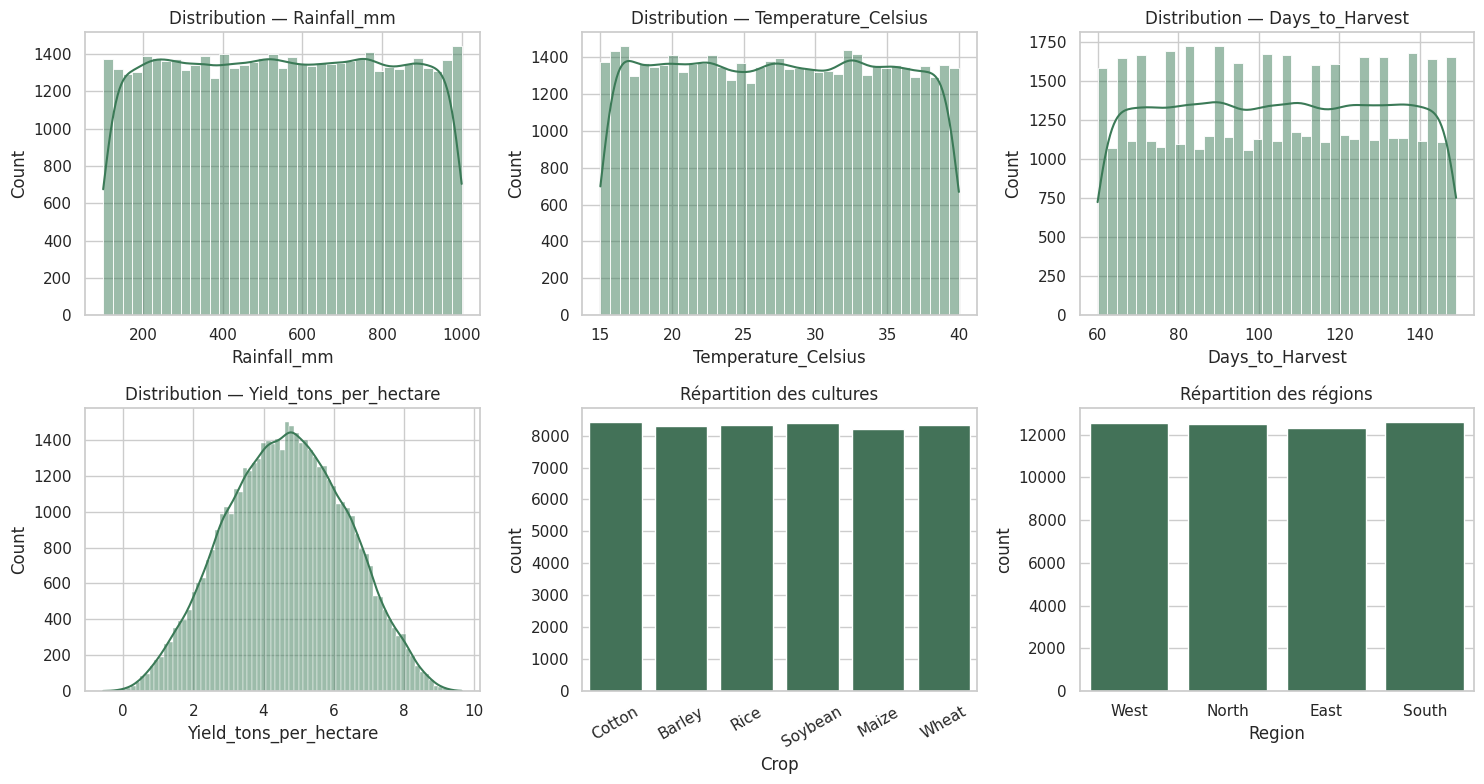

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
sample = df_parcels.sample(50_000, random_state=RNG)

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(sample[col], kde=True, ax=ax, color="#3b7a57")
    ax.set_title(f"Distribution — {col}")

sns.countplot(data=sample, x="Crop", ax=axes.flat[4], color="#3b7a57")
axes.flat[4].set_title("Répartition des cultures")
axes.flat[4].tick_params(axis="x", rotation=30)

sns.countplot(data=sample, x="Region", ax=axes.flat[5], color="#3b7a57")
axes.flat[5].set_title("Répartition des régions")

plt.tight_layout()
plt.savefig("../reports/fig_distributions_parcelles.png", bbox_inches="tight")
plt.show()


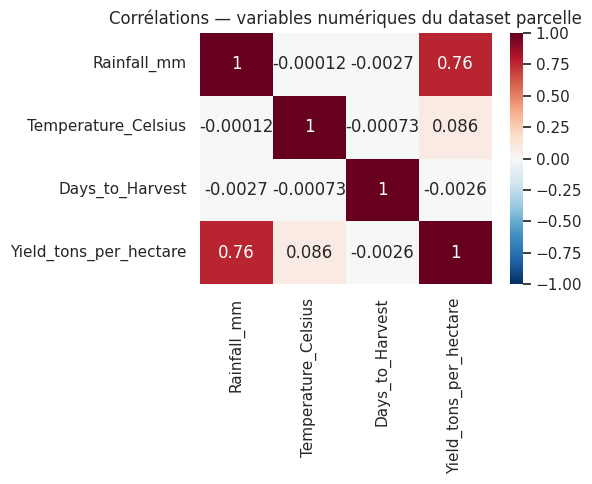

In [7]:
plt.figure(figsize=(6, 5))
corr = df_parcels[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, center=0)
plt.title("Corrélations — variables numériques du dataset parcelle")
plt.tight_layout()
plt.savefig("../reports/fig_correlations_parcelles.png", bbox_inches="tight")
plt.show()


Les corrélations linéaires entre variables numériques brutes et le rendement sont
**faibles** : cela suggère que le rendement dépend surtout des variables catégorielles
(culture, sol, irrigation, engrais) et/ou d'interactions non-linéaires.

## 3. Exploration — CropYield Prediction Dataset (niveau pays / année)

Ce second dataset (source FAO) fournit des indicateurs climatiques et agronomiques
réels, mais à une granularité différente (pays × année × culture, et non parcelle).


In [8]:
df_world.info()


<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.9 MB


In [9]:
print("Doublons :", df_world.duplicated().sum())
print("Période couverte :", df_world['Year'].min(), "-", df_world['Year'].max())
print("Nombre de pays :", df_world['Area'].nunique())
print("Cultures couvertes :", sorted(df_world['Item'].unique()))


Doublons : 2310
Période couverte : 1990 - 2013
Nombre de pays : 101
Cultures couvertes : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']


**Constat important :** 2 310 lignes strictement dupliquées sont présentes (A supprimer). Par ailleurs, la variable `pesticides_tonnes` est en réalité un total national de pesticides tous produits confondus : c'est une limitation à garder en tête dans l'interprétation.


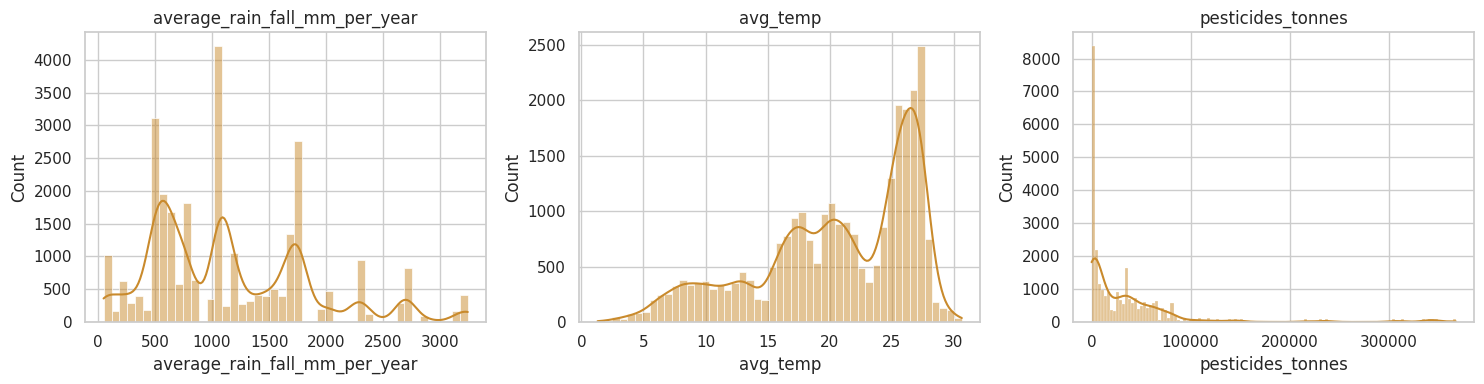

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]):
    sns.histplot(df_world[col], kde=True, ax=ax, color="#c98a2c")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/fig_distributions_monde.png", bbox_inches="tight")
plt.show()


## 4. Stratégie de fusion

Les deux datasets **ne partagent pas de clé pays/année** (le dataset parcelle n'a ni
pays ni année). Une jointure directe pays+année est donc impossible.

**Stratégie retenue :** utiliser la **culture (`Crop` / `Item`)** comme clé de
jointure, en agrégeant le CropYield Prediction Dataset par culture (moyenne sur tous
pays et toutes années 1990-2013) pour obtenir des **valeurs de référence mondiales**
par culture : pluviométrie moyenne, température moyenne, usage moyen de pesticides,
rendement moyen mondial.

Ces indicateurs sont ensuite fusionnés sur chaque ligne du dataset parcelle
correspondant à la même culture, et utilisés pour calculer des **variables d'écart**
(proxy) :
- `rainfall_gap_pct` : écart en % entre la pluviométrie de la parcelle et la moyenne
  mondiale pour cette culture ;
- `temperature_gap_c` : écart en °C entre la température de la parcelle et la moyenne
  mondiale pour cette culture.

**Correspondance des noms de cultures** (les deux sources n'utilisent pas toujours le
même nom) :


In [11]:
print(CROP_NAME_MAPPING)
print("\nCultures du dataset parcelle sans correspondance FAO directe :", CROPS_WITHOUT_FAO_MATCH)


{'rice, paddy': 'rice', 'soybeans': 'soybean', 'maize': 'maize', 'wheat': 'wheat'}

Cultures du dataset parcelle sans correspondance FAO directe : {'barley', 'cotton'}


`Barley` (orge) et `Cotton` (coton) n'ont pas d'équivalent dans le CropYield
Prediction Dataset. **Limitation documentée** : pour ces deux cultures, j'applique la
moyenne mondiale *tous produits confondus* comme valeur de repli plutôt que de
supprimer ces cultures (qui représentent ~1/3 des lignes du dataset
parcelle).


In [12]:
df_parcels_clean = clean_parcels_dataset(df_parcels)
df_world_clean = clean_world_dataset(df_world)
benchmarks = build_crop_benchmarks(df_world_clean)
benchmarks


,Item_norm,world_avg_rainfall_mm,world_avg_temp_c,world_avg_pesticides_tonnes,world_avg_yield_t_ha
0,cassava,1499.553203,24.287898,40346.332864,14.564969
1,maize,1092.824529,19.752186,30802.178734,3.713932
2,plantains and others,1853.928058,24.243543,7931.009874,10.604132
3,potatoes,1051.516178,18.824684,30231.396848,19.866573
4,rice,1188.624717,21.180162,34913.989647,4.129603
5,sorghum,1008.509747,21.285715,34746.022783,1.909977
6,soybean,1112.565306,19.438605,38822.023816,1.699219
7,sweet potatoes,1239.661010,22.181693,37317.574960,11.965652
8,wheat,939.018649,17.853018,33585.047567,3.012568
9,yams,1629.701550,23.191176,64664.802661,11.210563


In [13]:
merged = merge_datasets(df_parcels_clean, benchmarks)
print(merged.shape)
merged.head()


(1000000, 17)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,Crop_norm,world_avg_rainfall_mm,world_avg_temp_c,world_avg_pesticides_tonnes,world_avg_yield_t_ha,rainfall_gap_pct,temperature_gap_c
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,cotton,1261.590295,21.223868,35336.037976,8.267719,-28.893140,6.453098
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,rice,1188.624717,21.180162,34913.989647,4.129603,-16.485560,-3.154020
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,barley,1261.590295,21.223868,35336.037976,8.267719,-88.268931,8.570174
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,soybean,1112.565306,19.438605,38822.023816,1.699219,-11.298121,-2.794415
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,wheat,939.018649,17.853018,33585.047567,3.012568,-22.218885,13.767670


In [14]:
print("Valeurs manquantes après fusion :", merged.isna().sum().sum())
print("Lignes avec rendement négatif corrigé à 0 :", df_parcels_clean.attrs['n_negative_yield_clipped'])


Valeurs manquantes après fusion : 0
Lignes avec rendement négatif corrigé à 0 : 231


## 5. Analyse en Composantes Principales (ACP)

Objectif : identifier, parmi toutes les variables disponibles (initiales + variables
d'écart créées lors de la fusion), celles qui expliquent le plus la variabilité du
rendement — et donc les variables clés à surveiller pour un agriculteur.

Je standardise (centrage-réduction) toutes les variables numériques et j'encode les
variables catégorielles en indicatrices avant de lancer l'ACP.


In [15]:
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest",
    "world_avg_rainfall_mm", "world_avg_temp_c", "world_avg_pesticides_tonnes",
    "world_avg_yield_t_ha", "rainfall_gap_pct", "temperature_gap_c",
    "Yield_tons_per_hectare",
]
bool_features = ["Fertilizer_Used", "Irrigation_Used"]

pca_sample = merged.sample(20_000, random_state=RNG).reset_index(drop=True)

X_num = pca_sample[numeric_features].astype(float)
X_bool = pca_sample[bool_features].astype(int)
X_pca_input = pd.concat([X_num, X_bool], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

pca = PCA(random_state=RNG)
pca_coords = pca.fit_transform(X_scaled)

print("Variance expliquée par composante :", pca.explained_variance_ratio_.round(3))


Variance expliquée par composante : [0.248 0.208 0.162 0.099 0.087 0.083 0.083 0.023 0.004 0.001 0.    0.   ]


### 5.1 Choix du nombre de composantes (scree plot)

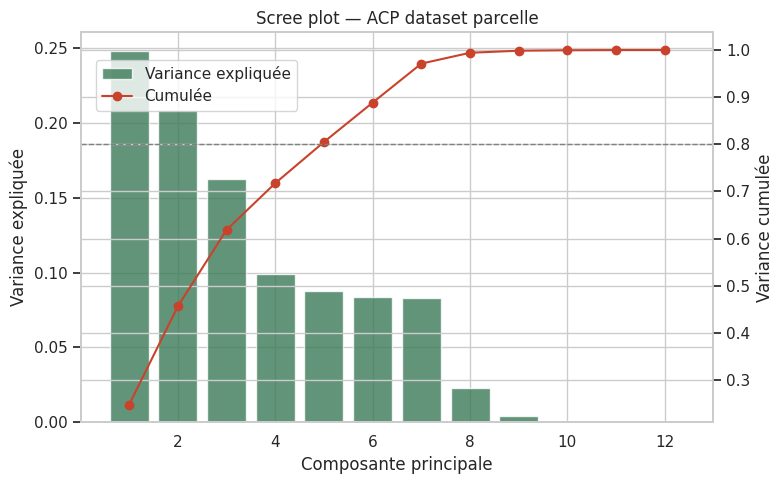

F1+F2 expliquent 45.7% de la variance totale


In [16]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(range(1, len(explained) + 1), explained, color="#3b7a57", alpha=0.8, label="Variance expliquée")
ax1.set_xlabel("Composante principale")
ax1.set_ylabel("Variance expliquée")
ax2 = ax1.twinx()
ax2.plot(range(1, len(explained) + 1), cumulative, color="#c9432c", marker="o", label="Cumulée")
ax2.set_ylabel("Variance cumulée")
ax2.axhline(0.8, color="grey", linestyle="--", linewidth=1)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.title("Scree plot — ACP dataset parcelle")
plt.tight_layout()
plt.savefig("../reports/fig_pca_scree.png", bbox_inches="tight")
plt.show()

print(f"F1+F2 expliquent {cumulative[1]*100:.1f}% de la variance totale")


### 5.2 Cercle des corrélations (F1, F2)

Le cercle des corrélations montre la contribution de chaque variable initiale aux
deux premiers axes principaux. Une variable proche du bord du cercle est bien
représentée sur ce plan ; deux variables proches l'une de l'autre sont corrélées
positivement, à l'opposé négativement, à 90° non corrélées.


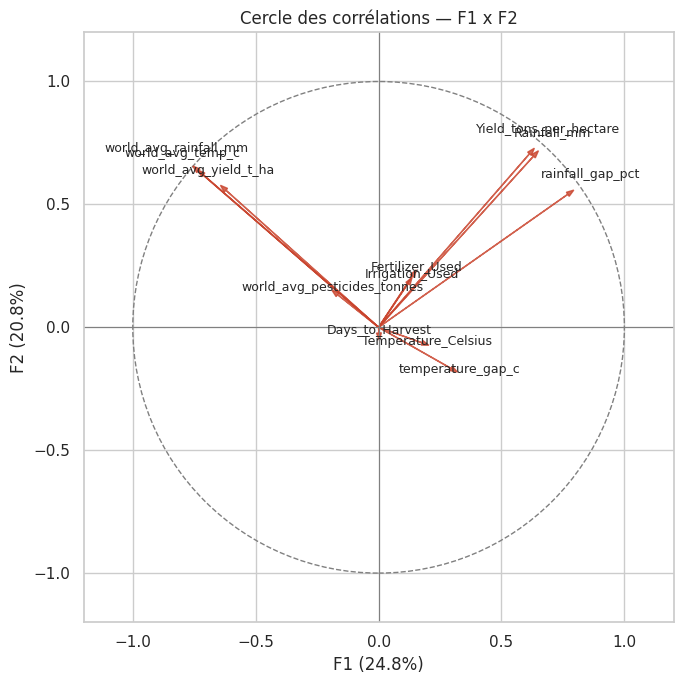

In [17]:
loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])

fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 1, facecolor="none", edgecolor="grey", linestyle="--")
ax.add_patch(circle)

for i, feature in enumerate(X_pca_input.columns):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.02, color="#c9432c", alpha=0.8)
    ax.text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12, feature, fontsize=9, ha="center")

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel(f"F1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"F2 ({explained[1]*100:.1f}%)")
ax.set_title("Cercle des corrélations — F1 x F2")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../reports/fig_pca_cercle_correlations.png", bbox_inches="tight")
plt.show()


In [18]:
contrib = pd.DataFrame(
    {"F1": pca.components_[0], "F2": pca.components_[1]},
    index=X_pca_input.columns,
).abs().sort_values("F1", ascending=False)
contrib


,F1,F2
rainfall_gap_pct,0.446014,0.342055
world_avg_rainfall_mm,0.424946,0.402491
world_avg_temp_c,0.413386,0.392190
Rainfall_mm,0.365214,0.440090
world_avg_yield_t_ha,0.359893,0.352581
Yield_tons_per_hectare,0.355832,0.446354
temperature_gap_c,0.170965,0.105845
Temperature_Celsius,0.102256,0.039829
world_avg_pesticides_tonnes,0.096504,0.083864
Fertilizer_Used,0.079370,0.131774


### 5.3 Projection des individus sur le premier plan factoriel


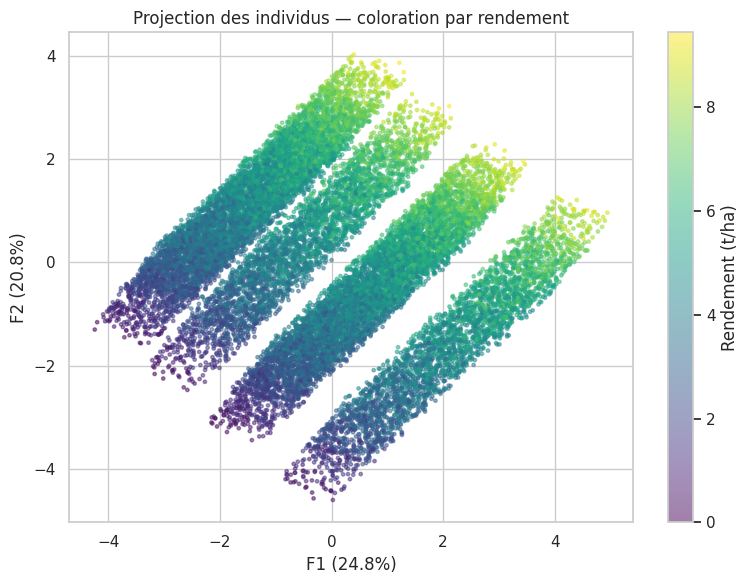

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=pca_sample["Yield_tons_per_hectare"], cmap="viridis", s=6, alpha=0.5,
)
plt.colorbar(scatter, label="Rendement (t/ha)")
ax.set_xlabel(f"F1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"F2 ({explained[1]*100:.1f}%)")
ax.set_title("Projection des individus — coloration par rendement")
plt.tight_layout()
plt.savefig("../reports/fig_pca_individus.png", bbox_inches="tight")
plt.show()


### 5.4 Interprétation — variables clés identifiées par l'ACP

- **F1** est structuré principalement par les variables *monde* liées à la culture
  (`world_avg_pesticides_tonnes`, `world_avg_rainfall_mm`, `world_avg_temp_c`,
  `world_avg_yield_t_ha`) : cet axe oppose surtout les cultures entre elles
  (leur profil climatique et agronomique moyen), plus qu'il ne discrimine le
  rendement au sein d'une même culture.
- **F2** capte davantage les variables *parcelle* (`Rainfall_mm`,
  `Temperature_Celsius`, écarts à la moyenne mondiale) et se rapproche le plus de la
  direction du rendement observé.
- Le nuage de points projeté ne montre **pas de séparation nette** du rendement selon
  F1/F2 seuls : cela confirme l'intuition vue en partie 2 (corrélations linéaires
  faibles) — le rendement dépend d'une **combinaison non-linéaire** de variables
  (notamment `Irrigation_Used`, `Fertilizer_Used`, `Soil_Type`, qui ne sont pas
  linéairement séparables en 2D). Cela justifie le choix, à l'étape suivante, de
  modèles non-linéaires (Random Forest / Gradient Boosting) plutôt qu'une simple
  régression linéaire.
- Variables clés retenues pour le modèle : `Crop`, `Region`, `Soil_Type`,
  `Irrigation_Used`, `Fertilizer_Used`, `Rainfall_mm`, `Temperature_Celsius`,
  `Days_to_Harvest`, ainsi que les variables d'écart mondiales créées lors de la
  fusion.


## 6. Export du dataset consolidé


In [20]:
merged_full, stats = build_merged_dataset("../data/raw")
print(stats)

import os
os.makedirs("../data/processed", exist_ok=True)
merged_full.to_csv("../data/processed/merged_dataset.csv", index=False)
print("Export terminé :", merged_full.shape)


{'n_rows_parcels_raw': 1000000, 'n_rows_parcels_clean': 1000000, 'n_negative_yield_clipped': 231, 'n_duplicates_removed_world': 2310, 'n_rows_merged': 1000000, 'n_missing_after_merge': 0, 'crops_with_fao_match': ['maize', 'rice', 'soybean', 'wheat'], 'crops_fallback': ['barley', 'cotton']}


Export terminé : (1000000, 17)


## 7. Résumé

- **Fusion** : jointure par culture (et non pays/année, absent du dataset parcelle),
  avec agrégation du CropYield Prediction Dataset en benchmarks mondiaux par culture.
- **Nettoyage** : suppression de 2 310 doublons dans le CropYield Prediction Dataset ;
  correction de 231 rendements négatifs (mis à 0) dans le dataset parcelle ; aucune
  valeur manquante après fusion.
- **Limitation documentée** : Barley et Cotton n'ont pas de correspondance FAO directe
  → moyenne mondiale tous produits confondus utilisée en repli. Les pesticides FAO
  sont un total national, pas spécifique à la culture.
- **Variables clés identifiées (ACP + corrélations)** : la culture elle-même, le mode
  d'irrigation et d'engrais, le sol, ainsi que les écarts de pluviométrie/température
  par rapport aux normales mondiales de la culture.
- **Dataset final** : `data/processed/merged_dataset.csv`, 1 000 000 lignes, 0 valeur
  manquante, prêt pour l'entraînement des modèles.
